# App Reviews Data Preparation
## Cleaning and Labeling Google Play Store Reviews for Domain Shift Testing

**Project Team: Group K**
**Date:** June 2026

---

## 1. Problem Definition & Introduction

### Goal
To prepare a brand new test set using Google App Reviews. This dataset represents a **Domain Shift** from the Twitter training data, as it contains structured product feedback rather than general social media posts.

### Why App Reviews?
App reviews are highly opinionated and contain clear sentiment signals (emotional words, specific complaints, or praise). This makes them an excellent target for testing how well our models generalize to "Product Review" domains.

## 2. Importing the necessary Libraries
> **Note:** These are the same libraries used in the main Sentiment Analysis notebook to ensure consistency.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="pastel")

## 3. Data Loading
Loading the raw app reviews gathered for this project.

In [2]:
raw_data_path = '../data/raw/app_reviews_raw.csv'
df_app = pd.read_csv(raw_data_path)
print(f"Loaded {len(df_app)} raw reviews.")
df_app.head()

Loaded 300 raw reviews.


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,sortOrder,appId
0,gp:AOqpTOEkQbdd0UFIKK0IWLAYs_hY2H2wPWYh73nfpOL...,Syed Tazrian Ahmed Shampricto,https://lh3.googleusercontent.com/a-/AOh14Gh4O...,Awesome!! Easy to use......just perfect!!!!,5,0,15.8.2,2020-07-22 20:15:31,NaN,NaN,newest,com.todoist
1,gp:AOqpTOFmT3JA_N0f8SsXEe8h-MHKW6udUgFeiLnZZ8i...,Adrian,https://lh3.googleusercontent.com/-A9Q-0bFoFuQ...,"I like this app, because it fits well in my da...",4,2,2.37.9,2020-03-22 14:28:34,NaN,NaN,most_relevant,com.appgenix.bizcal
2,gp:AOqpTOEy9Ykhegsj5M9LHKTE946jR-lC-9_F6BLOpxJ...,Jarek Bartoszek,https://lh3.googleusercontent.com/a-/AOh14Ggyr...,"I am a vanilla habitician, but that game faile...",5,14,2.23.0,2020-03-14 12:20:16,Thanks for such great and encouraging review!\...,2020-03-18 16:38:55,most_relevant,com.levor.liferpgtasks
3,gp:AOqpTOEJPMfbSZIVxeKJkrVkOVvxZ2CiH5H8GNnwIgk...,Upakul Talukdar,https://lh3.googleusercontent.com/a-/AOh14GiSd...,The best app for people with or without ADHD,5,0,2.6.2,2020-06-01 05:40:12,NaN,NaN,newest,com.habitrpg.android.habitica
4,gp:AOqpTOHigl_24rNtAH100KKBnXjWFxd8CBCMGIJxnkH...,Amanda Ollenburger,https://lh3.googleusercontent.com/a-/AOh14Gid0...,Great tool for coordinating between family mem...,5,0,2.23.163,2020-08-03 22:26:21,NaN,NaN,most_relevant,com.microsoft.todos


## 4. Exploratory Data Analysis (EDA)
### 4.1 Distribution of Ratings (Scores)
Understanding the balance of the raw dataset using the star ratings.

/var/folders/sd/166t63ln65vds5p00p5lf4w40000gn/T/ipykernel_78526/2623968749.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='score', data=df_app, palette='viridis')


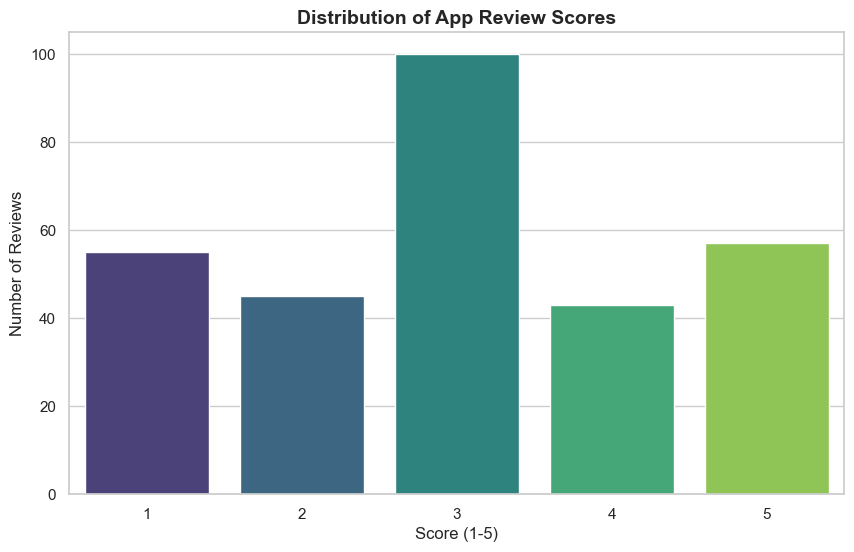

In [3]:
plt.figure(figsize=(10, 6))
sns.countplot(x='score', data=df_app, palette='viridis')
plt.title('Distribution of App Review Scores', fontsize=14, fontweight='bold')
plt.xlabel('Score (1-5)', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.show()

### 4.2 Text Length Analysis
Analyzing how long the reviews are. This helps us compare the domain structure to Twitter (which is usually shorter).

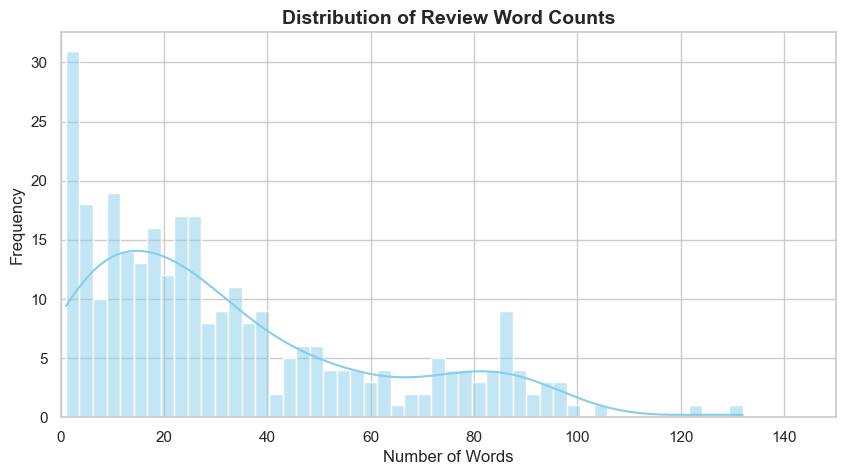

In [4]:
df_app['text_length'] = df_app['content'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(df_app['text_length'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Review Word Counts', fontsize=14, fontweight='bold')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.xlim(0, 150) # Most reviews are within this range
plt.show()

## 5. Data Cleaning And Preprocessing
### 5.1 Text Cleaning Pipeline
We use the exact same cleaning logic as the main notebook to ensure the data format matches the training data.

In [5]:
def clean_the_text(text):
    if not isinstance(text, str):
        return ""
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove specific noise characters (!!!, ???, @user)
    text = re.sub(r'!!!|\?\?\?|@user', '', text)
    
    # Remove excessive whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

df_app['clean_text'] = df_app['content'].apply(clean_the_text)
df_app = df_app.drop_duplicates(subset=['clean_text']).reset_index(drop=True)
print(f"Records after cleaning and deduplication: {len(df_app)}")

Records after cleaning and deduplication: 292


## 6. Sentiment Labeling Strategy
### 6.1 Mapping Scores to Sentiment Classes
As discussed, we map the 1-5 scores to Positive, Neutral, and Negative categories.

In [6]:
def map_sentiment(score):
    if score <= 2:
        return 'Negative'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Positive'

df_app['sentiment'] = df_app['score'].apply(map_sentiment)
df_app[['content', 'score', 'sentiment']].head(10)

,content,score,sentiment
0,Awesome!! Easy to use......just perfect!!!!,5,Positive
1,"I like this app, because it fits well in my da...",4,Positive
2,"I am a vanilla habitician, but that game faile...",5,Positive
3,The best app for people with or without ADHD,5,Positive
4,Great tool for coordinating between family mem...,5,Positive
5,"Add ""negative habits"" which when done decrease...",4,Positive
6,Seems good for people who use a calendar alrea...,4,Positive
7,Almost perfect. The only changes that would be...,4,Positive
8,The widget is quite imlressive,4,Positive
9,"This was a solid replacement for wunderlist, b...",4,Positive


### 6.2 Manual Verification Prompt
> **Instruction for David:** Madam mentioned labeling the data yourselves. While the scores provide a great baseline, you should manually review a sample (e.g., 200 reviews) to ensure the `sentiment` column accurately reflects the `content`. 
>
> **Add code here** to export a small sample for manual review if needed.

## 7. Saving the Processed Test Set
Saving the final cleaned and labeled dataset to the processed data folder.

In [7]:
output_path = '../data/processed/app_reviews_test.csv'
df_app[['clean_text', 'sentiment']].to_csv(output_path, index=False)
print(f"Success! Cleaned App Reviews test set saved to: {output_path}")

Success! Cleaned App Reviews test set saved to: ../data/processed/app_reviews_test.csv
